## Neural Network

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Load data

In [15]:
col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(
    "census+income/adult.data",
    header=None,
    names=col_names,
    sep=r",\s*",
    engine="python",
    na_values="?"
)

df = df.drop(columns=["fnlwgt"])

df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
y = (df["income"] == ">50K").astype(int)
X = df.drop(columns=["income"])

## Organize features
same process as logistic regression for best comparison

In [16]:
numeric_features = [
    "age", "education_num", "capital_gain", "capital_loss", "hours_per_week"
]

categorical_features = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=11,
    stratify=y
)

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

## Convert to PyTorch tensors

In [19]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

X_train_tensor = torch.tensor(X_train_processed.toarray(), dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_processed.toarray(), dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

Using device: cpu


## Define MLP model
two hidden layers: one of size 64 and the other of size 32

In [20]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

model = MLP(X_train_tensor.shape[1]).to(device)


## Train model

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 5/50, Loss: 0.6549
Epoch 10/50, Loss: 0.6236
Epoch 15/50, Loss: 0.5883
Epoch 20/50, Loss: 0.5483
Epoch 25/50, Loss: 0.5046
Epoch 30/50, Loss: 0.4603
Epoch 35/50, Loss: 0.4194
Epoch 40/50, Loss: 0.3853
Epoch 45/50, Loss: 0.3609
Epoch 50/50, Loss: 0.3469


In [23]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_tensor)
    y_pred_tensor = torch.argmax(outputs, dim=1)

y_pred = y_pred_tensor.cpu().numpy()

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("MLP Accuracy:", accuracy)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred))

MLP Accuracy: 0.8368750767718953

Confusion matrix:
 [[5638  543]
 [ 785 1175]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      6181
           1       0.68      0.60      0.64      1960

    accuracy                           0.84      8141
   macro avg       0.78      0.76      0.77      8141
weighted avg       0.83      0.84      0.83      8141



,class,precision,recall
0,0,0.877783,0.91215
1,1,0.683935,0.59949


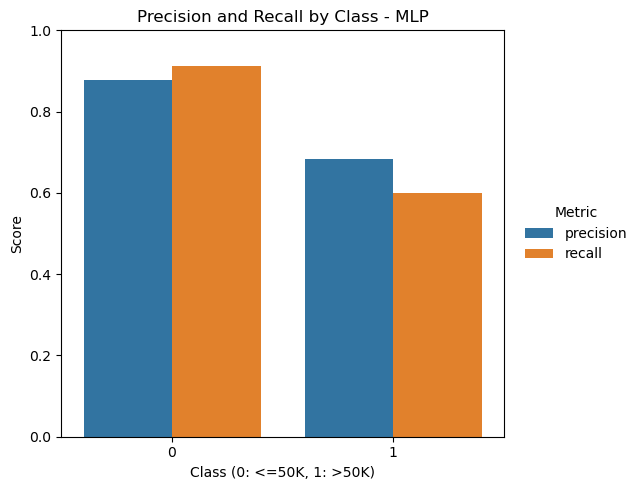

In [24]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

display(metrics_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=metrics_long,
    x="class",
    y="score",
    hue="metric",
    ax=ax
)
ax.set_ylim(0, 1)
ax.set_title("Precision and Recall by Class - MLP")
ax.set_xlabel("Class (0: <=50K, 1: >50K)")
ax.set_ylabel("Score")
ax.legend(title="Metric", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

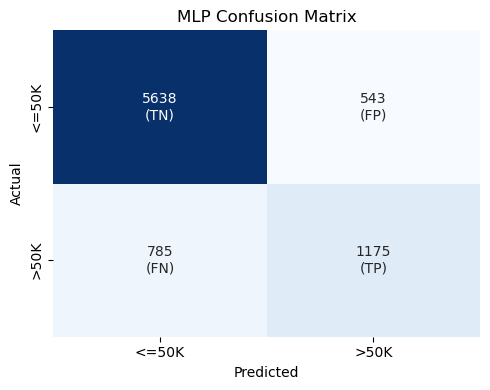

In [25]:
cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
annot_labels = np.array([
    [f"{cm[i, j]}\n({cell_labels[i, j]})" for j in range(2)]
    for i in range(2)
], dtype=object)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
os.makedirs("exports", exist_ok=True)
mlp_cm_path = os.path.join("exports", "mlp_confusion_matrix.csv")
np.savetxt(mlp_cm_path, cm, fmt="%d", delimiter=",")
print(f"Saved MLP confusion matrix to: {mlp_cm_path}")

Saved MLP confusion matrix to: exports/mlp_confusion_matrix.csv
